In [12]:
import os
import math
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from codec import DataCodec
from IPython.display import display
from collections import Counter

In [13]:
def get_entropy_ratio(file_path):
    """Розраховує ентропію та повертає її як коефіцієнт (0.0 - 1.0)"""
    try:
        with open(file_path, 'rb') as f:
            data = f.read()
        if not data: return 0

        counts = Counter(data)
        entropy = 0
        for count in counts.values():
            p = count / len(data)
            entropy -= p * math.log2(p)

        #8 біт = 1.0 (неможливо стиснути вже стиснутий файл, повторів нема)
        return entropy / 8
    except:
        return 0

In [14]:
def visualize_results(df, title_suffix=""):
    if df.empty: return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_style("white")

    sns.barplot(x='algorithm', y='ratio', data=df, ax=axes[0],
                palette='viridis', hue='algorithm', legend=False)

    axes[0].set_title(f'Коефіцієнт стиснення {title_suffix}', fontsize=12, fontweight='bold')

    axes[0].axhline(1, color='red', linestyle='--', label='Original', zorder=5)

    if 'entropy_limit' in df.columns:
        ent_val = df['entropy_limit'].iloc[0]
        axes[0].axhline(ent_val, color='magenta', linestyle='--', linewidth=1.5,
                        label=f'Entropy Limit ({ent_val:.3f})', zorder=6)

    axes[0].legend(frameon=True, loc='upper right')
    axes[0].grid(axis='y', linestyle=':', alpha=0.7)

    #ГРАФІК 2
    df_time = df.melt(id_vars=['algorithm', 'is_valid'],
                      value_vars=['compress_time_ms', 'decompress_time_ms'],
                      var_name='Type', value_name='Time_ms')

    sns.barplot(x='algorithm', y='Time_ms', hue='Type', data=df_time,
                ax=axes[1], palette='magma')

    axes[1].set_title(f'Час роботи (мс) {title_suffix}', fontsize=12, fontweight='bold')
    axes[1].set_yscale('log')

    axes[1].grid(False, which='both', axis='both')
    axes[1].yaxis.grid(True, which='major', color='#DDDDDD', linestyle='--')


    for i, algo_name in enumerate(df['algorithm']):
        row = df[df['algorithm'] == algo_name].iloc[0]
        if not row['is_valid']:
            axes[0].text(i, row['ratio'], 'FAIL', ha='center', va='bottom', color='red', fontweight='bold')


            for ax in axes:
                for patch in ax.patches:
                    if abs(patch.get_x() + patch.get_width()/2 - i) < 0.4:
                        patch.set_alpha(0.15)
                        patch.set_edgecolor('red')

    plt.tight_layout()
    plt.show()

In [15]:
def run_full_analysis(file_paths, algorithms=None):
    """
    Проганяє тести для списку файлів і будує графіки для кожного.
    """
    codec = DataCodec()
    if algorithms is None:
        algorithms = ['lzw', 'arithmetic', 'huffman']

    for path in file_paths:
        if not os.path.exists(path):
            print(f"Файл {path} не знайдено, пропускаємо.")
            continue

        entropy = get_entropy_ratio(path)
        results = []
        print(f"\n>>> Аналіз файлу: {path}")

        for algo in algorithms:
            try:
                res = codec.test_algorithm(path, algo)
                if res:
                    results.append(res)
                    res['entropy_limit'] = entropy
            except Exception as e:
                print(f"Помилка {algo}: {e}")

        df = pd.DataFrame(results)
        file_name = os.path.basename(path)
        visualize_results(df, title_suffix=f"({file_name})")

        display(df[['algorithm', 'ratio', 'entropy_limit', 'compress_time_ms', 'decompress_time_ms', 'is_valid']])


>>> Аналіз файлу: tests_samples\smaragdove_nebo.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 140 bytes
  Ratio: 0.636x
  Compress time: 0.27 ms
  Decompress time: 0.50 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 153 bytes
  Ratio: 0.695x
  Compress time: 1.66 ms
  Decompress time: 2.36 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 165 bytes
  Ratio: 0.750x
  Compress time: 0.62 ms
  Decompress time: 0.32 ms


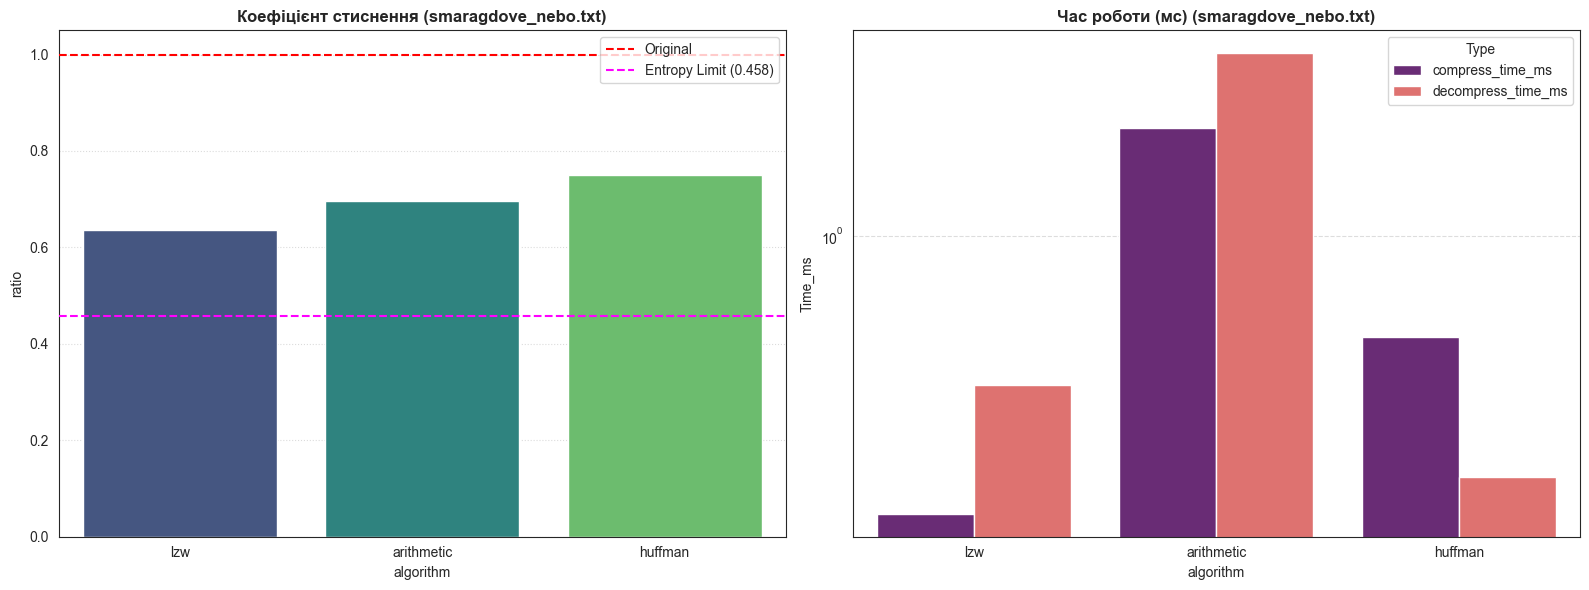

,algorithm,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.636364,0.457806,0.270128,0.495434,True
1,arithmetic,0.695455,0.457806,1.663685,2.360106,True
2,huffman,0.750000,0.457806,0.622034,0.320435,True



>>> Аналіз файлу: tests_samples\franko.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 39,437 bytes
  Ratio: 0.343x
  Compress time: 82.99 ms
  Decompress time: 38.59 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 60,234 bytes
  Ratio: 0.523x
  Compress time: 708.97 ms
  Decompress time: 1045.54 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 60,669 bytes
  Ratio: 0.527x
  Compress time: 137.42 ms
  Decompress time: 202.82 ms


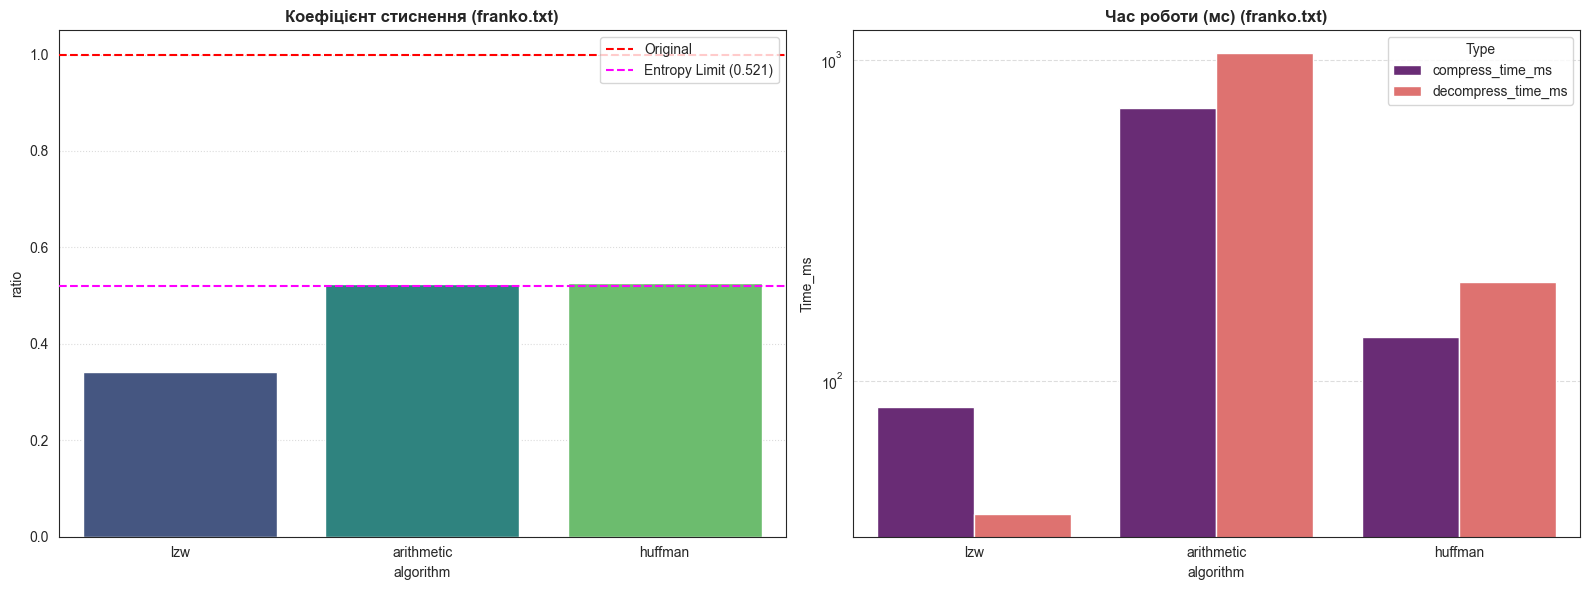

,algorithm,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.342662,0.521018,82.994461,38.585424,True
1,arithmetic,0.523364,0.521018,708.974361,1045.537949,True
2,huffman,0.527144,0.521018,137.421131,202.820301,True



>>> Аналіз файлу: tests_samples\world.json

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,108,741 -> 843,482 bytes
  Ratio: 0.400x
  Compress time: 1363.67 ms
  Decompress time: 805.86 ms

TESTING ARITHMETIC
--------------------------------------------------


KeyboardInterrupt: 

In [17]:
# Виклик аналізу для різних типів файлів
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastiry.bmp"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "CelineDion_MyHeartWillGoOn.flac")
]

run_full_analysis(files_to_test)


>>> Аналіз файлу: tests_samples\kobzar.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 139,879 bytes
  Ratio: 0.334x
  Compress time: 252.71 ms
  Decompress time: 152.50 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 226,639 bytes
  Ratio: 0.541x
  Compress time: 1765.26 ms
  Decompress time: 2166.93 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 227,854 bytes
  Ratio: 0.544x
  Compress time: 251.79 ms
  Decompress time: 334.33 ms


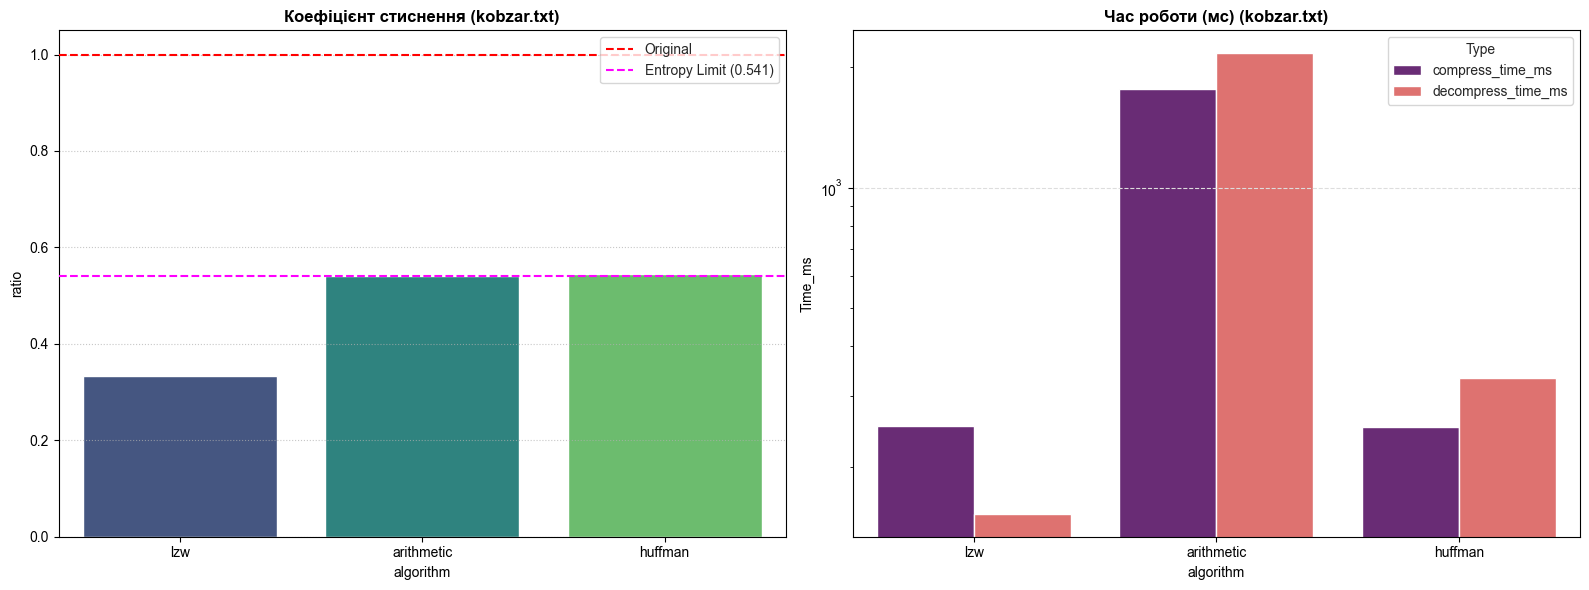

,algorithm,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.334075,0.540524,252.710104,152.501583,True
1,arithmetic,0.541284,0.540524,1765.262604,2166.925192,True
2,huffman,0.544186,0.540524,251.786232,334.330082,True



>>> Аналіз файлу: tests_samples\Назар_проєкти.ogg

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 160,446 -> 219,785 bytes
  Ratio: 1.370x
  Compress time: 537.59 ms
  Decompress time: 151.47 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 160,446 -> 160,092 bytes
  Ratio: 0.998x
  Compress time: 1046.26 ms
  Decompress time: 1221.55 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 160,446 -> 160,634 bytes
  Ratio: 1.001x
  Compress time: 151.26 ms
  Decompress time: 270.39 ms


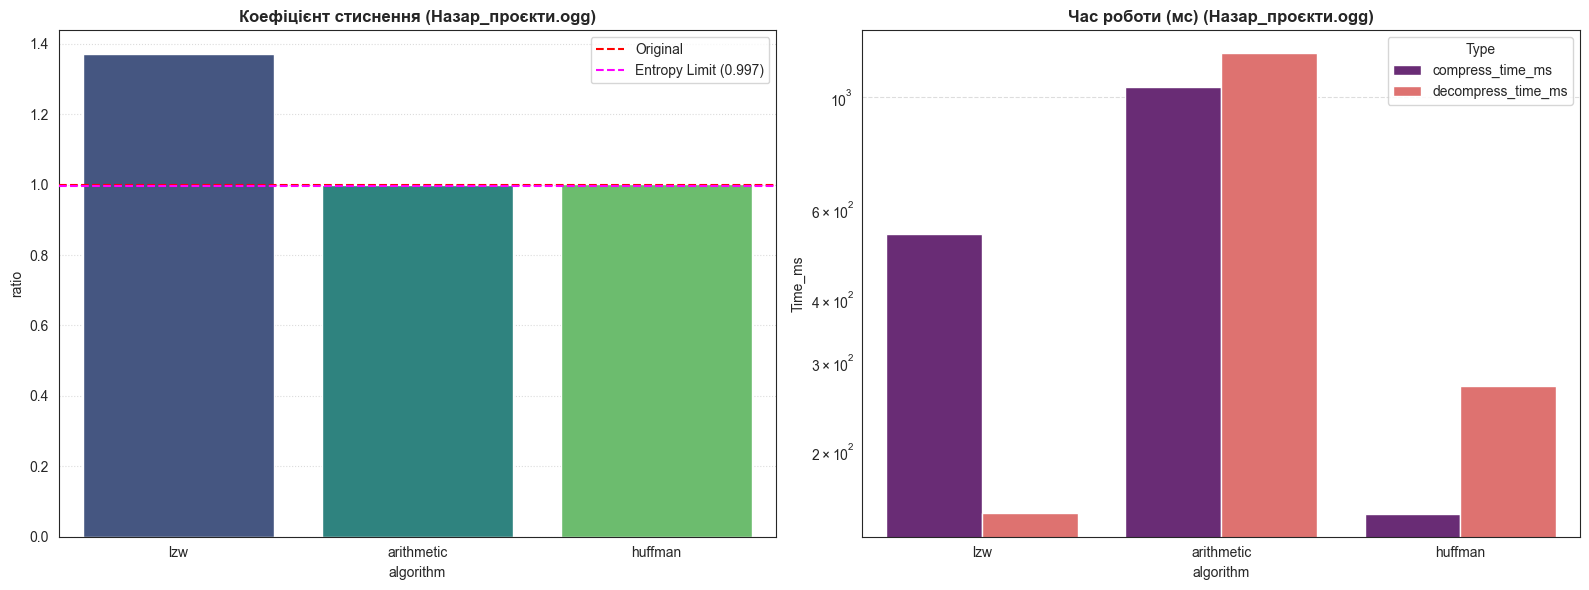

,algorithm,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,lzw,1.369838,0.996822,537.588596,151.469231,True
1,arithmetic,0.997794,0.996822,1046.256065,1221.554995,True
2,huffman,1.001172,0.996822,151.261806,270.394564,True



>>> Аналіз файлу: tests_samples\large_file.json

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 26,152,697 -> 6,941,457 bytes
  Ratio: 0.265x
  Compress time: 10427.29 ms
  Decompress time: 4500.88 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 26,152,697 -> 16,995,438 bytes
  Ratio: 0.650x
  Compress time: 178563.91 ms
  Decompress time: 203579.33 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 26,152,697 -> 17,103,523 bytes
  Ratio: 0.654x
  Compress time: 17131.33 ms
  Decompress time: 26989.40 ms


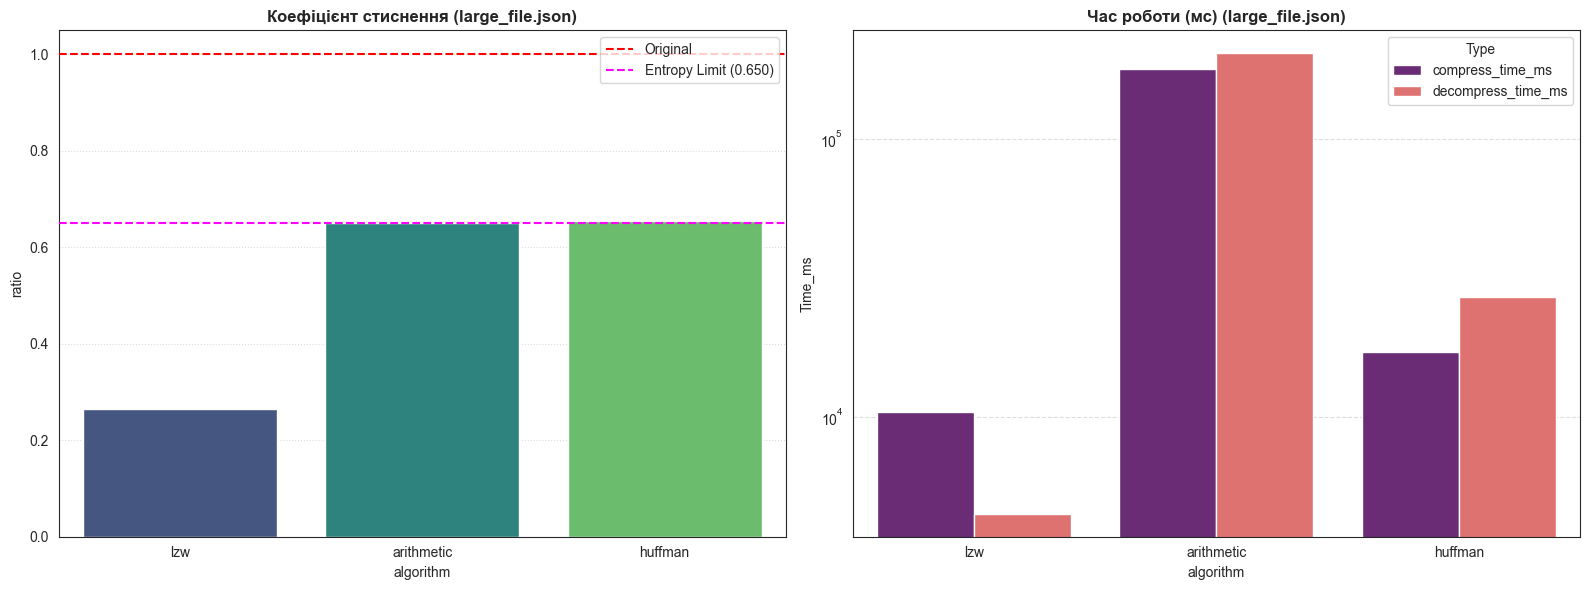

,algorithm,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.265420,0.649838,10427.294254,4500.875711,True
1,arithmetic,0.649854,0.649838,178563.909054,203579.328299,True
2,huffman,0.653987,0.649838,17131.328583,26989.401340,True



>>> Аналіз файлу: tests_samples\smooth_operator.wav

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,695,482 -> 3,405,976 bytes
  Ratio: 1.264x
  Compress time: 2858.79 ms
  Decompress time: 1794.72 ms

TESTING ARITHMETIC
--------------------------------------------------


KeyboardInterrupt: 

In [ ]:
files_to_test = [
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "fast_reading.avi")
]
algorithms = ['lzw', 'arithmetic', 'huffman']
run_full_analysis(files_to_test, algorithms)


>>> Аналіз файлу: tests_samples\smaragdove_nebo.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 244 bytes
  Ratio: 1.109x
  Compress time: 0.19 ms
  Decompress time: 0.15 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 248 bytes
  Ratio: 1.127x
  Compress time: 1.13 ms
  Decompress time: 0.13 ms

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 138 bytes
  Ratio: 0.627x
  Compress time: 0.19 ms
  Decompress time: 13.36 ms

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 440 bytes
  Ratio: 2.000x
  Compress time: 0.07 ms
  Decompress time: 0.12 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 153 bytes
  Ratio: 0.695x
  Compress time: 1.32 ms
  Decompress time: 1.64 ms

TESTING DEFLATE
------

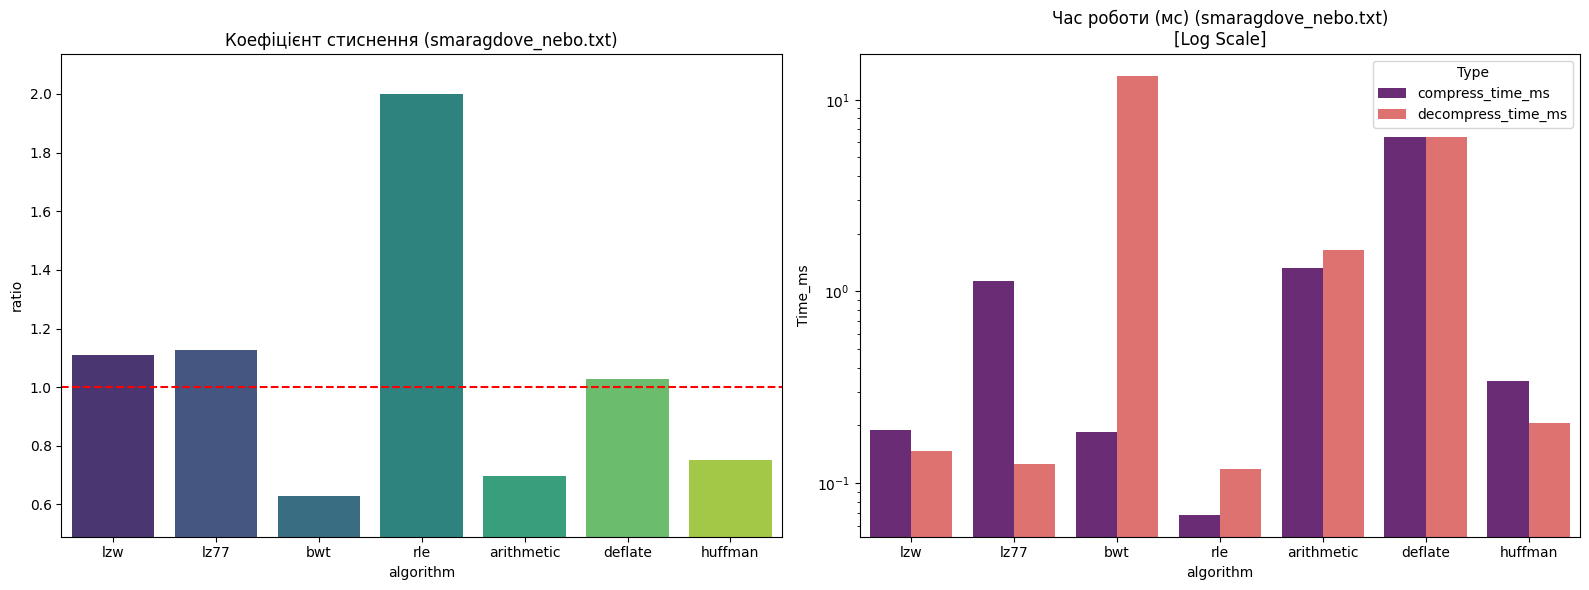

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,1.109091,0.190020,0.147820,True
1,lz77,1.127273,1.132011,0.125170,True
2,bwt,0.627273,0.185728,13.357878,True
3,rle,2.000000,0.068426,0.118017,True
4,arithmetic,0.695455,1.322746,1.636982,True
5,deflate,1.027273,6.409883,6.380796,True
6,huffman,0.750000,0.339508,0.206947,True



>>> Аналіз файлу: tests_samples\letters.csv

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 302 bytes
  Ratio: 0.296x
  Compress time: 0.43 ms
  Decompress time: 0.18 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 110 bytes
  Ratio: 0.108x
  Compress time: 4.38 ms
  Decompress time: 0.13 ms

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 66 bytes
  Ratio: 0.065x
  Compress time: 0.96 ms
  Decompress time: 229.54 ms

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 60 bytes
  Ratio: 0.059x
  Compress time: 0.11 ms
  Decompress time: 0.04 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 546 bytes
  Ratio: 0.535x
  Compress time: 4.56 ms
  Decompress time: 5.38 ms

TESTING DEFLATE
-----

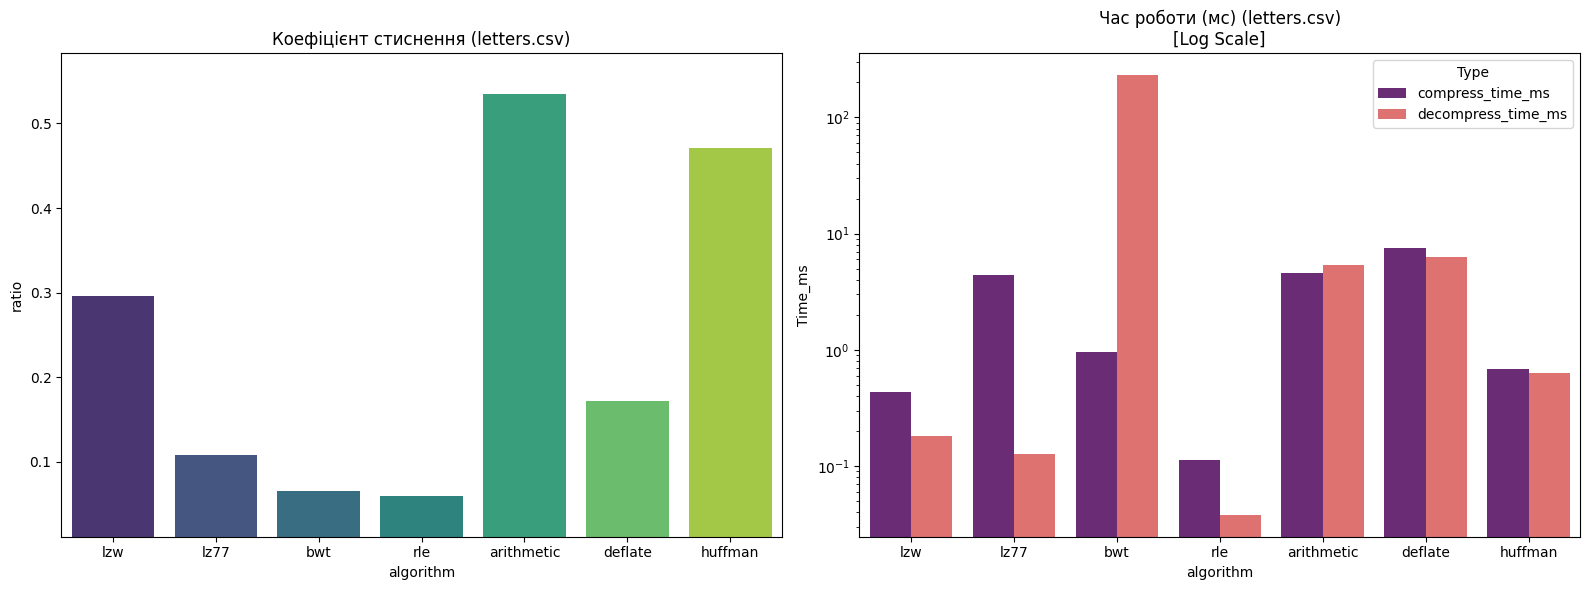

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.296078,0.431061,0.181437,True
1,lz77,0.107843,4.384279,0.128031,True
2,bwt,0.064706,0.960827,229.540825,True
3,rle,0.058824,0.111818,0.038147,True
4,arithmetic,0.535294,4.555702,5.382061,True
5,deflate,0.171569,7.575750,6.300449,True
6,huffman,0.470588,0.681162,0.634193,True


In [ ]:
algorithms = ['lzw', 'lz77', 'bwt', 'rle', 'arithmetic', 'deflate', 'huffman']
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "letters.csv"),
]

run_full_analysis(files_to_test, algorithms)


ще можна додати щоб якось позначалося який алгоритм в кожному графіку найшвидший/найефевтипінший


>>> Аналіз файлу: tests_samples\the_life_of_dickens.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,671,895 -> 1,130,882 bytes
  Ratio: 0.423x
  Compress time: 1740.36 ms
  Decompress time: 1070.24 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,671,895 -> 1,522,508 bytes
  Ratio: 0.570x
  Compress time: 15548.17 ms
  Decompress time: 19044.14 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,671,895 -> 1,536,376 bytes
  Ratio: 0.575x
  Compress time: 2731.36 ms
  Decompress time: 3001.66 ms


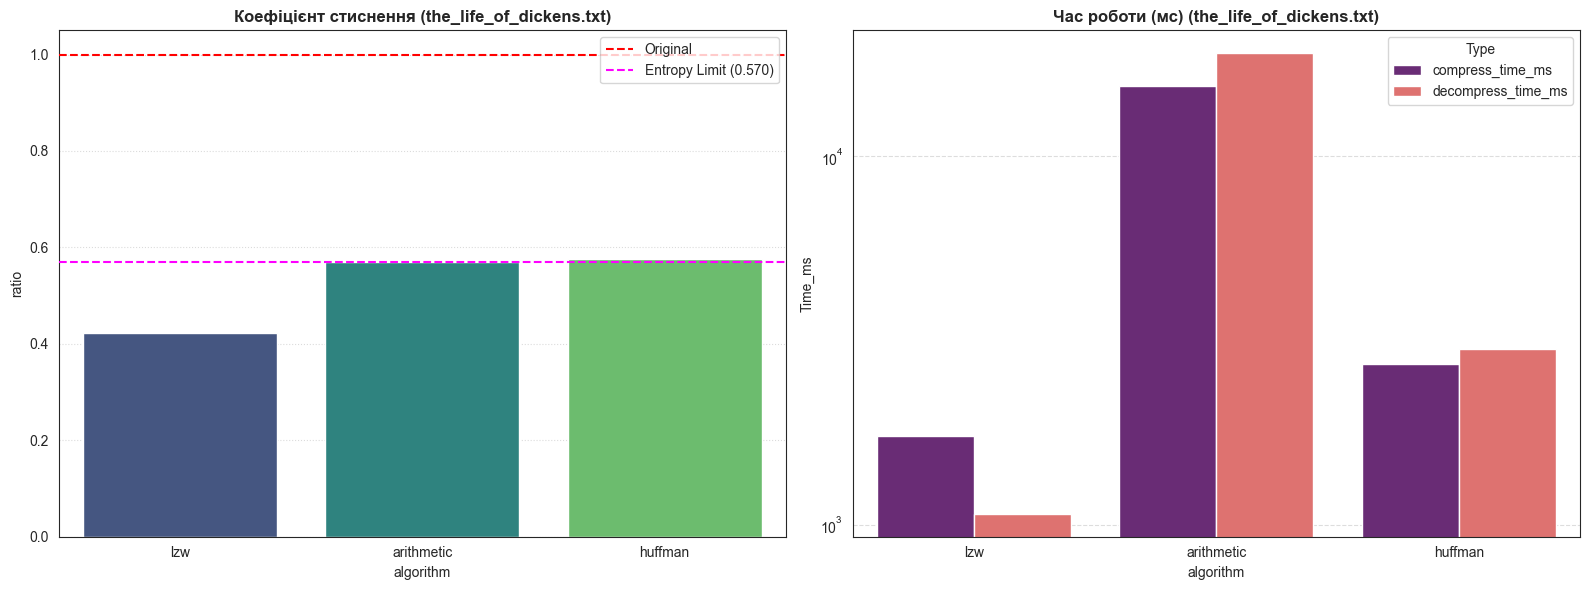

,algorithm,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.423251,0.569676,1740.360975,1070.243120,True
1,arithmetic,0.569823,0.569676,15548.167229,19044.137478,True
2,huffman,0.575014,0.569676,2731.357336,3001.656771,True


In [16]:
algorithms = ['lzw', 'arithmetic', 'huffman']
files_to_test = [
    os.path.join("tests_samples", "the_life_of_dickens.txt")
    ]

run_full_analysis(files_to_test, algorithms)



>>> Аналіз файлу: tests_samples\kobzar.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 139,879 bytes
  Ratio: 0.334x
  Compress time: 354.89 ms
  Decompress time: 195.86 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 226,639 bytes
  Ratio: 0.541x
  Compress time: 3267.30 ms
  Decompress time: 3777.43 ms

TESTING DEFLATE
--------------------------------------------------
Помилка deflate: Distance 28383 exceeds buffer bounds

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 227,854 bytes
  Ratio: 0.544x
  Compress time: 424.81 ms
  Decompress time: 495.89 ms


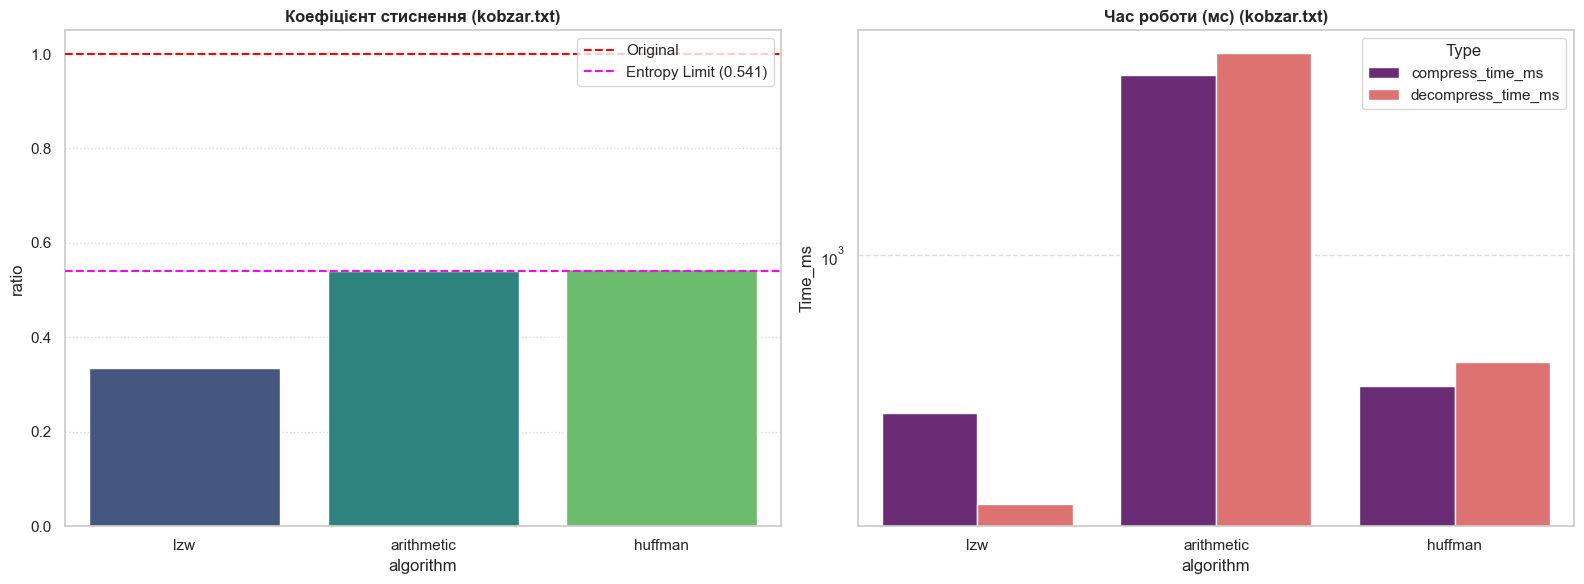

,algorithm,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.334075,0.540524,354.886293,195.860386,True
1,arithmetic,0.541284,0.540524,3267.297983,3777.430773,True
2,huffman,0.544186,0.540524,424.812078,495.893240,True


In [25]:
algorithms = ['lzw', 'arithmetic', 'deflate', 'huffman']
files_to_test = [
    os.path.join("tests_samples", "kobzar.txt")
    ]

run_full_analysis(files_to_test, algorithms)

In [17]:
def visualize_algo_across_files(df, algo_name):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    # 1. ГРАФІК: Ефективність стиснення
    sns.barplot(x='file_name', y='ratio', data=df, ax=axes[0],
                palette='viridis', hue='file_name', legend=False)

    axes[0].set_title(f'Ефективність стиснення: {algo_name}', fontsize=14, fontweight='bold')
    axes[0].axhline(1, color='red', linestyle='--', label='Original (100%)')

    # --- ДОДАВАННЯ ЕНТРОПІЇ ДЛЯ КОЖНОГО ФАЙЛУ ---
    if 'entropy_limit' in df.columns:
        # Малюємо сходинки (step plot), щоб межа ентропії відповідала кожному стовпчику
        x_indices = np.arange(len(df['file_name']))
        axes[0].step(x_indices, df['entropy_limit'], where='mid',
                     color='magenta', linewidth=2.5, label='Entropy Limit', marker='o', markersize=5)
        axes[0].legend()
    # --------------------------------------------

    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_ylabel('Ratio (менше = краще)')

    # 2. ГРАФІК: Час роботи
    df_time = df.melt(id_vars=['file_name', 'is_valid'],
                      value_vars=['compress_time_ms', 'decompress_time_ms'],
                      var_name='Phase', value_name='Time_ms')

    sns.barplot(x='file_name', y='Time_ms', hue='Phase', data=df_time,
                ax=axes[1], palette='coolwarm')

    axes[1].set_title(f'Швидкість роботи: {algo_name} (log scale)', fontsize=14, fontweight='bold')
    axes[1].set_yscale('log')
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_ylabel('Час (мс)')

    # Логіка FAIL та прозорості
    validity_map = dict(zip(df['file_name'], df['is_valid']))
    file_names = list(df['file_name'])

    for i, bar in enumerate(axes[0].patches):
        if i < len(file_names):
            f_name = file_names[i]
            if not validity_map[f_name]:
                bar.set_alpha(0.2)
                axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                             'FAIL', color='red', ha='center', va='bottom', fontweight='bold')

    num_files = len(file_names)
    for i, bar in enumerate(axes[1].patches):
        f_name = file_names[i % num_files]
        if not validity_map[f_name]:
            bar.set_alpha(0.2)
            if i < num_files:
                axes[1].text(bar.get_x() + bar.get_width(), bar.get_height(),
                             'FAIL', color='red', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Таблиця (додаємо колонку ентропії для порівняння)
    cols = ['file_name', 'ratio', 'compress_time_ms', 'decompress_time_ms', 'is_valid']
    if 'entropy_limit' in df.columns:
        cols.insert(2, 'entropy_limit')

    print(f"\nДетальна таблиця результатів для {algo_name}:")
    styled_df = df[cols].copy()
    styled_df['ratio'] = styled_df['ratio'].round(4)
    if 'entropy_limit' in styled_df.columns:
        styled_df['entropy_limit'] = styled_df['entropy_limit'].round(4)

    display(styled_df.sort_values(by='is_valid', ascending=True))

In [18]:
def run_single_algo_analysis(file_paths, target_algo):
    """
    Проганяє ОДИН алгоритм для списку файлів і будує порівняльний графік.
    """
    codec = DataCodec()
    all_results = []

    print(f"\n>>> Збір даних для алгоритму: {target_algo}")

    for path in file_paths:
        if not os.path.exists(path):
            print(f"Файл {path} не знайдено.")
            continue

        entropy = get_entropy_ratio(path)

        file_name = os.path.basename(path)
        try:
            res = codec.test_algorithm(path, target_algo)
            if res:
                res['file_name'] = file_name
                res['entropy_limit'] = entropy
                all_results.append(res)
        except Exception as e:
            print(f"Помилка при обробці {file_name}: {e}")

    if not all_results:
        print("Немає даних для візуалізації.")
        return

    df = pd.DataFrame(all_results)
    visualize_algo_across_files(df, target_algo)

тестування лзв.

In [ ]:
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastory.bmp"),
]

run_single_algo_analysis(files_to_test, target_algo='lz77')


>>> Збір даних для алгоритму: lz77

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 248 bytes
  Ratio: 1.127x
  Compress time: 0.45 ms
  Decompress time: 0.18 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 89,401 bytes
  Ratio: 0.777x
  Compress time: 621.58 ms
  Decompress time: 25.12 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 110 bytes
  Ratio: 0.108x
  Compress time: 0.32 ms
  Decompress time: 0.20 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,973 -> 7,680 bytes
  Ratio: 1.933x
  Compress time: 7.58 ms
  Decompress time: 2.15 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,523 -> 2,657 bytes
  Ratio: 1.745x
  Compress time: 1.88 ms
  Decompress time: 1.12 ms

TESTING LZ77
----------


>>> Збір даних для алгоритму: lzw

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 140 bytes
  Ratio: 0.636x
  Compress time: 0.29 ms
  Decompress time: 0.26 ms

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 139,879 bytes
  Ratio: 0.334x
  Compress time: 267.16 ms
  Decompress time: 144.60 ms

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 39,437 bytes
  Ratio: 0.343x
  Compress time: 77.03 ms
  Decompress time: 43.62 ms

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,276,227 -> 552,480 bytes
  Ratio: 0.433x
  Compress time: 1215.65 ms
  Decompress time: 767.64 ms

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,978,480 bytes
  Ratio: 1.082x
  Compress time: 4767.44 ms
  Decompress time: 3004.18

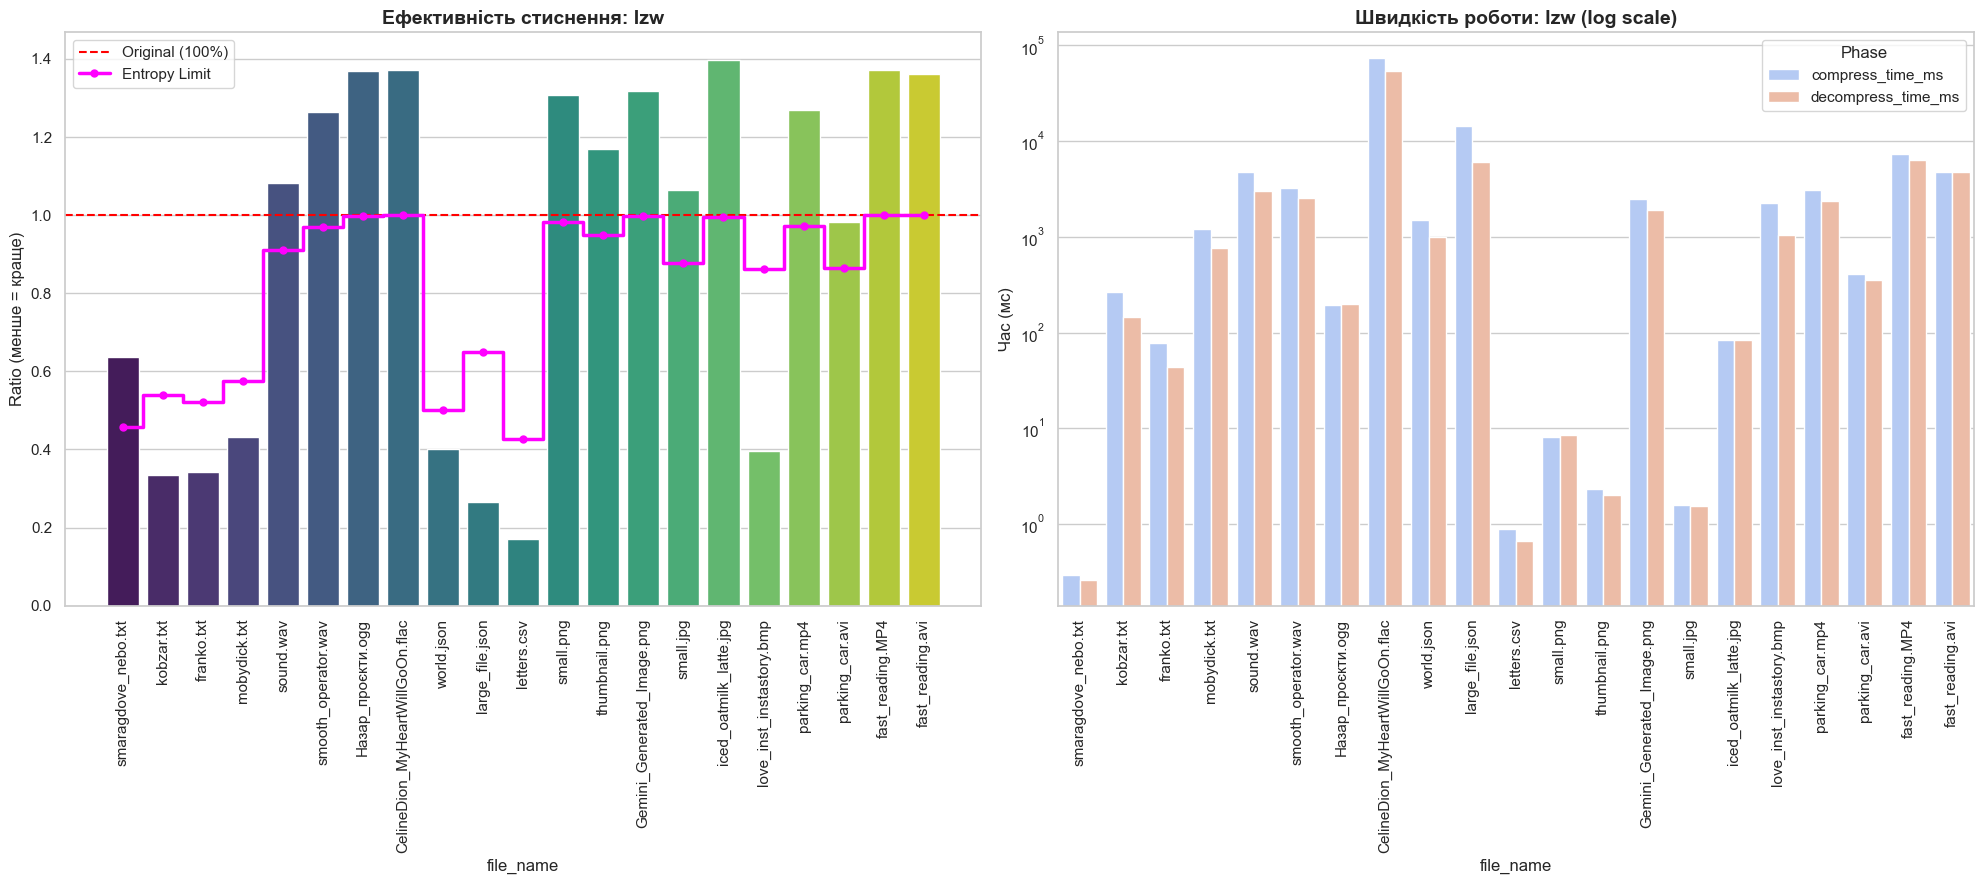


Детальна таблиця результатів для lzw:


,file_name,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,smaragdove_nebo.txt,0.6364,0.4578,0.293255,0.261545,True
18,parking_car.avi,0.9827,0.8648,410.084486,352.655411,True
17,parking_car.mp4,1.2683,0.9714,3121.930122,2386.840582,True
16,love_inst_instastory.bmp,0.3960,0.8626,2252.260685,1051.441193,True
15,iced_oatmilk_latte.jpg,1.3983,0.9964,83.045721,82.901001,True
14,small.jpg,1.0637,0.8775,1.558781,1.542330,True
13,Gemini_Generated_Image.png,1.3167,0.9977,2480.888605,1917.024851,True
12,thumbnail.png,1.1701,0.9500,2.305984,2.009630,True
11,small.png,1.3076,0.9820,8.033276,8.542061,True
19,fast_reading.MP4,1.3724,0.9999,7325.550795,6359.708786,True


In [19]:
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "mobydick.txt"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "CelineDion_MyHeartWillGoOn.flac"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "thumbnail.png"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastory.bmp"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "parking_car.avi"),
    os.path.join("tests_samples", "fast_reading.MP4"),
    os.path.join("tests_samples", "fast_reading.avi")
]

run_single_algo_analysis(files_to_test, target_algo='lzw')

Перевірка Гаффман на усіх типах файлів:


>>> Збір даних для алгоритму: huffman

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 165 bytes
  Ratio: 0.750x
  Compress time: 0.45 ms
  Decompress time: 0.31 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 418,706 -> 227,843 bytes
  Ratio: 0.544x
  Compress time: 569.47 ms
  Decompress time: 1260.66 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 115,090 -> 60,662 bytes
  Ratio: 0.527x
  Compress time: 387.24 ms
  Decompress time: 362.15 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 1,276,227 -> 738,798 bytes
  Ratio: 0.579x
  Compress time: 4551.65 ms
  Decompress time: 5655.28 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,362,231 bytes
  Ratio: 0.914x
  Compress time: 11674.12 

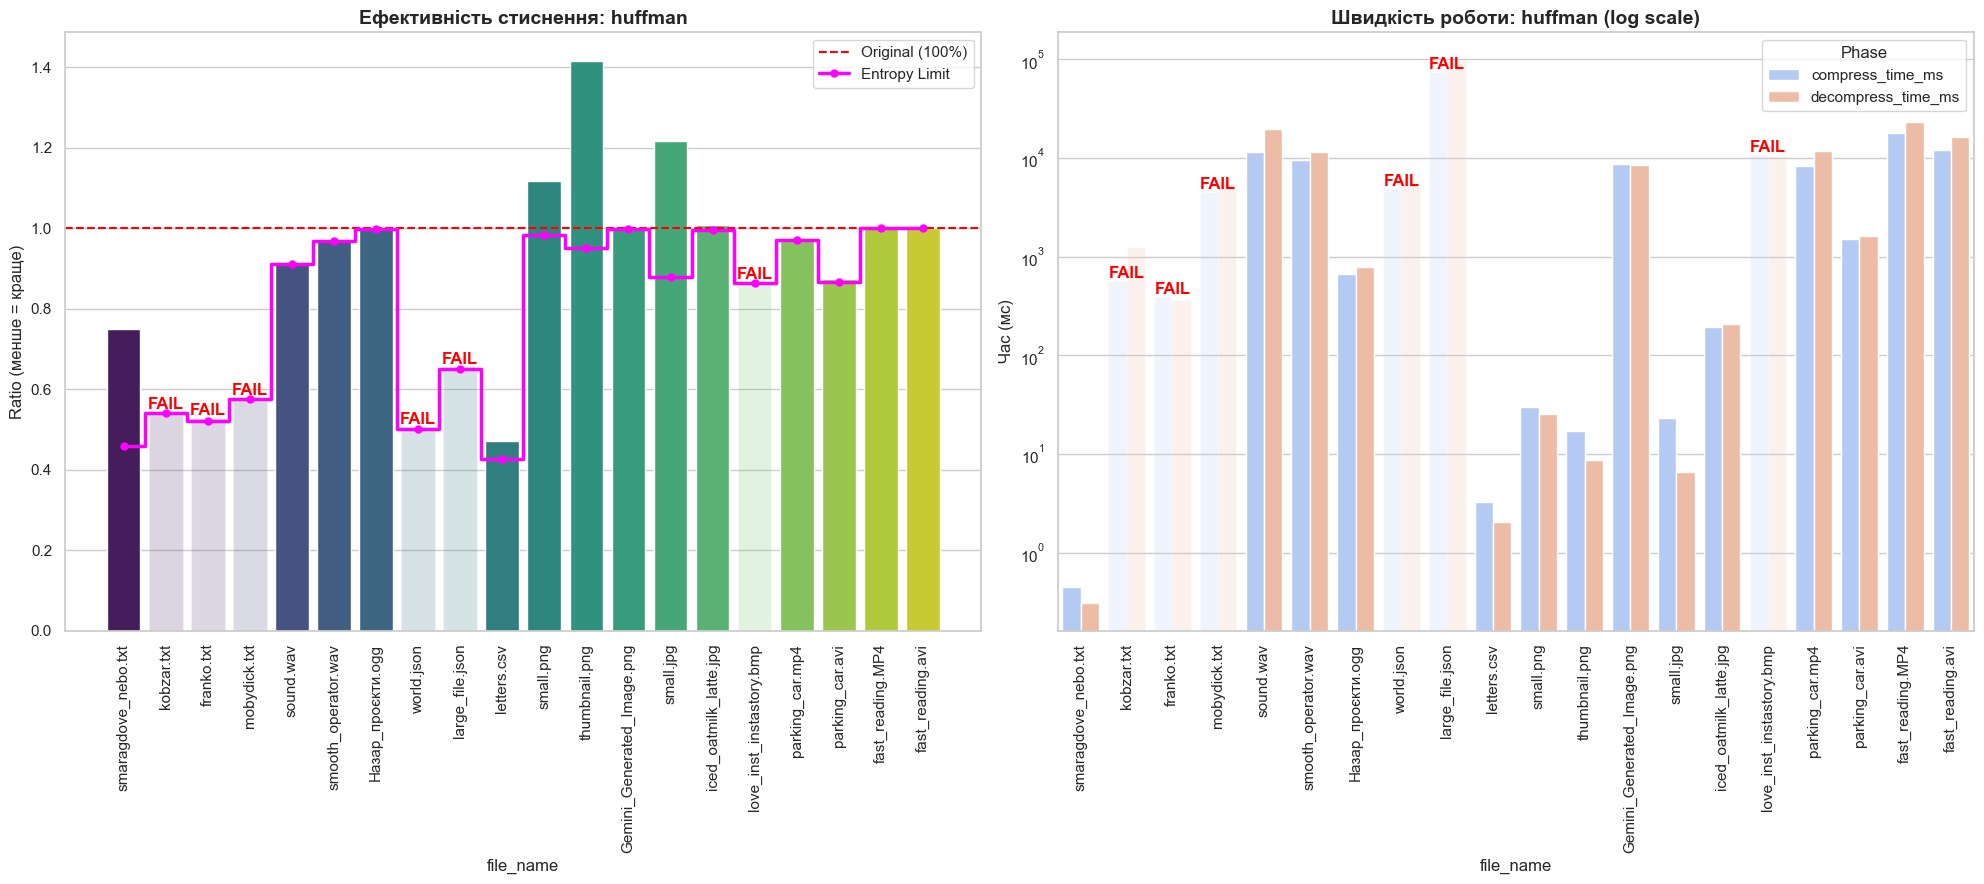


Детальна таблиця результатів для huffman:


,file_name,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
1,kobzar.txt,0.5442,0.5405,569.465876,1260.661602,False
2,franko.txt,0.5271,0.5210,387.243509,362.152576,False
3,mobydick.txt,0.5789,0.5747,4551.652193,5655.281782,False
15,love_inst_instastory.bmp,0.8672,0.8626,10763.531923,10627.270222,False
7,world.json,0.5051,0.5014,4904.868126,5485.048056,False
8,large_file.json,0.6539,0.6498,74277.961731,99914.048433,False
0,smaragdove_nebo.txt,0.7500,0.4578,0.451803,0.306368,True
17,parking_car.avi,0.8730,0.8648,1503.963232,1637.890577,True
16,parking_car.mp4,0.9752,0.9714,8354.085684,11790.333033,True
14,iced_oatmilk_latte.jpg,1.0072,0.9964,194.514513,207.799435,True


In [ ]:
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "mobydick.txt"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "thumbnail.png"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastory.bmp"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "parking_car.avi"),
    os.path.join("tests_samples", "fast_reading.MP4"),
    os.path.join("tests_samples", "fast_reading.avi")
]

run_single_algo_analysis(files_to_test, target_algo='huffman')

In [22]:
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "mobydick.txt"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "thumbnail.png"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastory.bmp"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "parking_car.avi"),
    os.path.join("tests_samples", "fast_reading.MP4"),
    os.path.join("tests_samples", "fast_reading.avi")
]

run_single_algo_analysis(files_to_test, target_algo='bwt')


>>> Збір даних для алгоритму: bwt

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 128 bytes
  Ratio: 0.582x
  Compress time: 3.09 ms
  Decompress time: 0.94 ms

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 199,860 bytes
  Ratio: 0.477x
  Compress time: 12804.16 ms
  Decompress time: 306.73 ms

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 57,595 bytes
  Ratio: 0.500x
  Compress time: 2819.05 ms
  Decompress time: 60.22 ms

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,276,227 -> 938,531 bytes
  Ratio: 0.735x
  Compress time: 59360.02 ms
  Decompress time: 1680.37 ms

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,464,083 bytes
  Ratio: 0.942x
  Compress time: 402276.08 ms
  Decompress time:

KeyboardInterrupt: 


>>> Збір даних для алгоритму: huffman

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 165 bytes
  Ratio: 0.750x
  Compress time: 0.54 ms
  Decompress time: 0.35 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 418,706 -> 227,843 bytes
  Ratio: 0.544x
  Compress time: 431.28 ms
  Decompress time: 450.91 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 115,090 -> 60,662 bytes
  Ratio: 0.527x
  Compress time: 103.29 ms
  Decompress time: 115.42 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 1,276,227 -> 738,798 bytes
  Ratio: 0.579x
  Compress time: 1204.04 ms
  Decompress time: 1559.08 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,362,231 bytes
  Ratio: 0.914x
  Compress time: 5064.83 ms

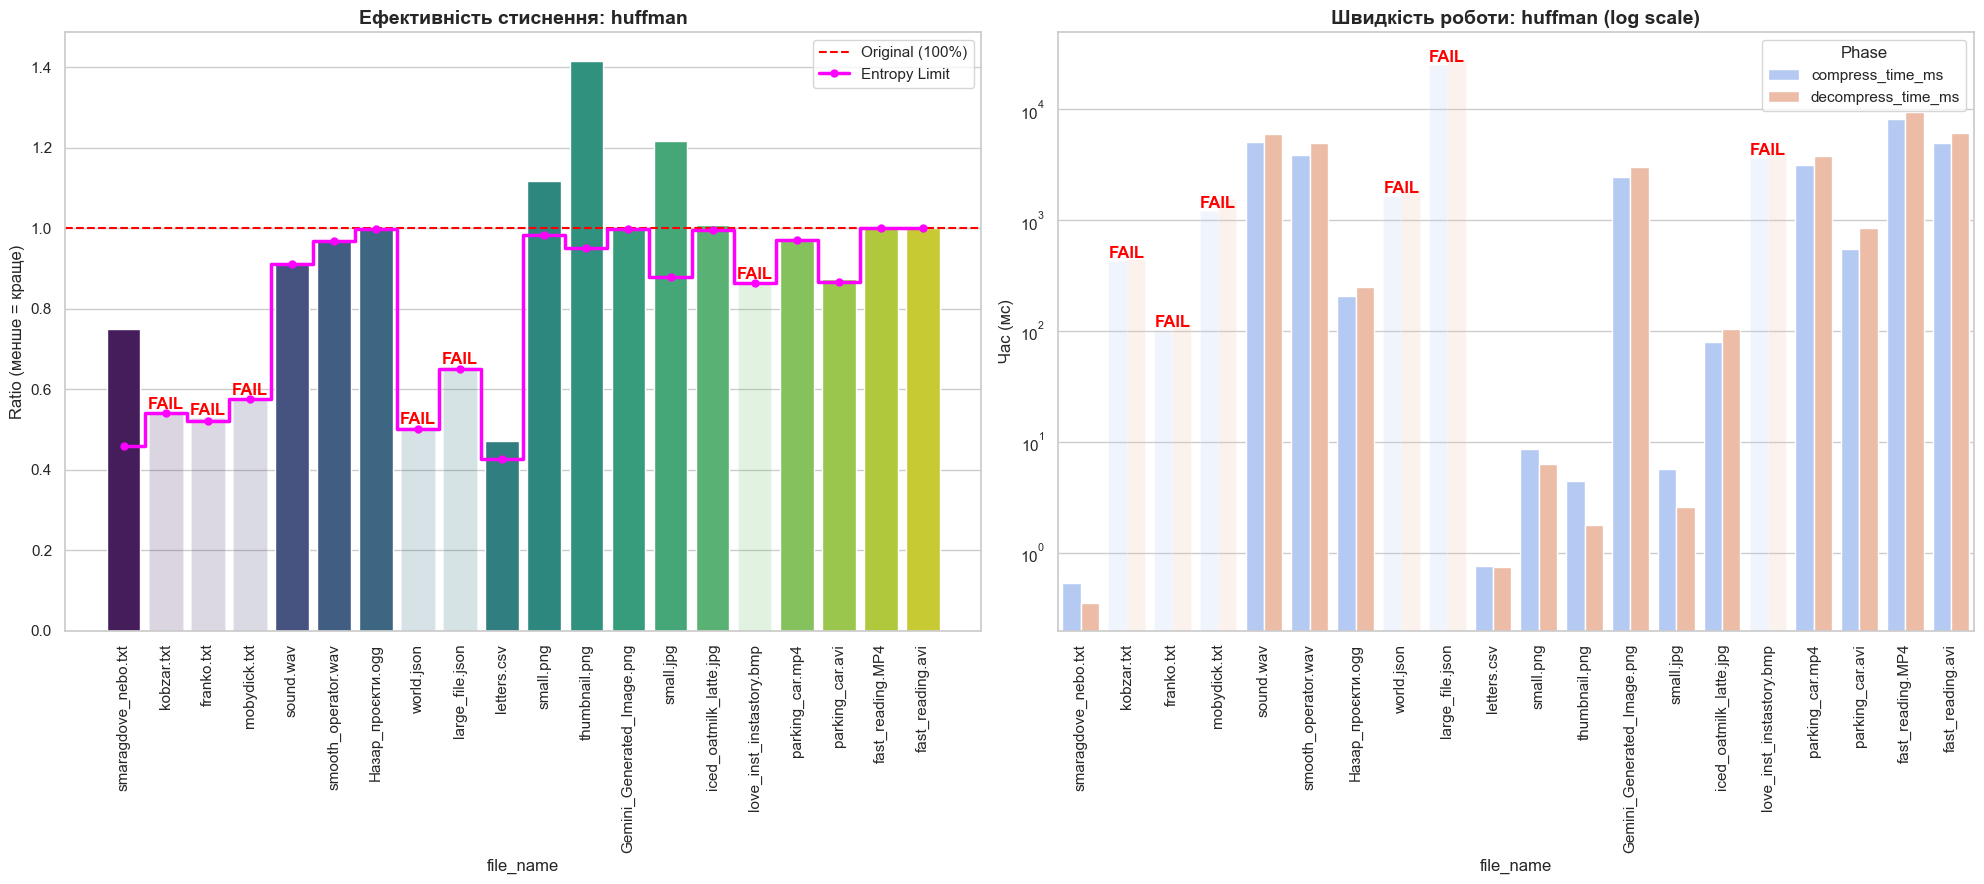


Детальна таблиця результатів для huffman:


,file_name,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
1,kobzar.txt,0.5442,0.5405,431.280613,450.909138,False
2,franko.txt,0.5271,0.5210,103.294134,115.424633,False
3,mobydick.txt,0.5789,0.5747,1204.039335,1559.082985,False
15,love_inst_instastory.bmp,0.8672,0.8626,3633.722782,4126.501322,False
7,world.json,0.5051,0.5014,1660.224915,1845.359564,False
8,large_file.json,0.6539,0.6498,25280.627966,28094.853163,False
0,smaragdove_nebo.txt,0.7500,0.4578,0.538588,0.351191,True
17,parking_car.avi,0.8730,0.8648,546.433687,847.619295,True
16,parking_car.mp4,0.9752,0.9714,3119.915724,3796.375513,True
14,iced_oatmilk_latte.jpg,1.0072,0.9964,80.283165,105.531216,True


In [ ]:
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "mobydick.txt"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "thumbnail.png"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastory.bmp"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "parking_car.avi"),
    os.path.join("tests_samples", "fast_reading.MP4"),
    os.path.join("tests_samples", "fast_reading.avi")
]

run_single_algo_analysis(files_to_test, target_algo='deflate')


>>> Збір даних для алгоритму: rle

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 222 bytes
  Ratio: 1.009x
  Compress time: 0.06 ms
  Decompress time: 0.02 ms

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 422,009 bytes
  Ratio: 1.008x
  Compress time: 95.13 ms
  Decompress time: 4.26 ms

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 116,006 bytes
  Ratio: 1.008x
  Compress time: 22.97 ms
  Decompress time: 1.37 ms

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,276,227 -> 1,286,083 bytes
  Ratio: 1.008x
  Compress time: 278.17 ms
  Decompress time: 7.55 ms

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,463,566 bytes
  Ratio: 0.942x
  Compress time: 785.45 ms
  Decompress time: 28.00 ms

TE

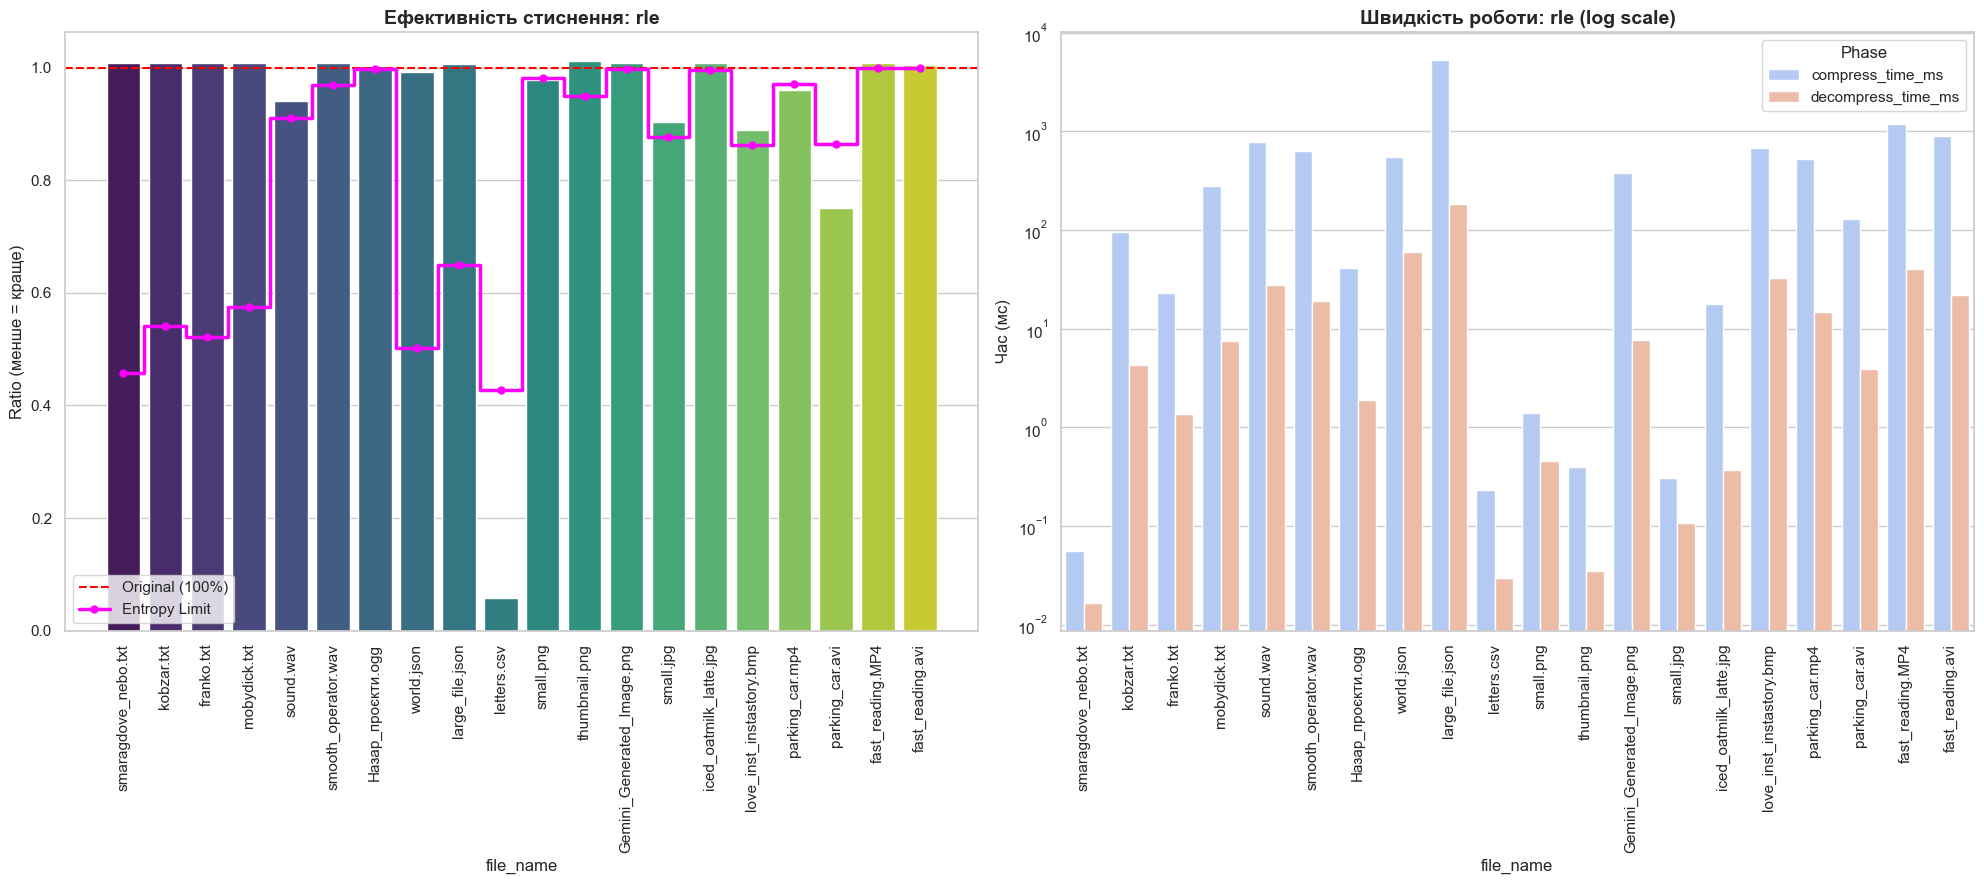


Детальна таблиця результатів для rle:


,file_name,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,smaragdove_nebo.txt,1.0091,0.4578,0.055313,0.016451,True
17,parking_car.avi,0.7505,0.8648,129.847288,3.947973,True
16,parking_car.mp4,0.9600,0.9714,527.070999,14.608860,True
15,love_inst_instastory.bmp,0.8892,0.8626,672.600508,32.366037,True
14,iced_oatmilk_latte.jpg,1.0075,0.9964,17.903328,0.365973,True
13,small.jpg,0.9035,0.8775,0.303745,0.108004,True
12,Gemini_Generated_Image.png,1.0080,0.9977,376.480341,7.664204,True
11,thumbnail.png,1.0122,0.9500,0.401258,0.034809,True
10,small.png,0.9781,0.9820,1.385212,0.458717,True
9,letters.csv,0.0588,0.4270,0.233412,0.029802,True


In [21]:
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "mobydick.txt"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "thumbnail.png"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastory.bmp"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "parking_car.avi"),
    os.path.join("tests_samples", "fast_reading.MP4"),
    os.path.join("tests_samples", "fast_reading.avi")
]

run_single_algo_analysis(files_to_test, target_algo='rle')

Арифметичне кодування


>>> Збір даних для алгоритму: arithmetic

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 153 bytes
  Ratio: 0.695x
  Compress time: 1.42 ms
  Decompress time: 1.69 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 226,639 bytes
  Ratio: 0.541x
  Compress time: 1846.03 ms
  Decompress time: 2271.58 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 60,234 bytes
  Ratio: 0.523x
  Compress time: 493.81 ms
  Decompress time: 620.98 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,276,227 -> 733,860 bytes
  Ratio: 0.575x
  Compress time: 5409.60 ms
  Decompress time: 10380.34 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,352,580 bytes
  Ratio: 0.911x
  Comp

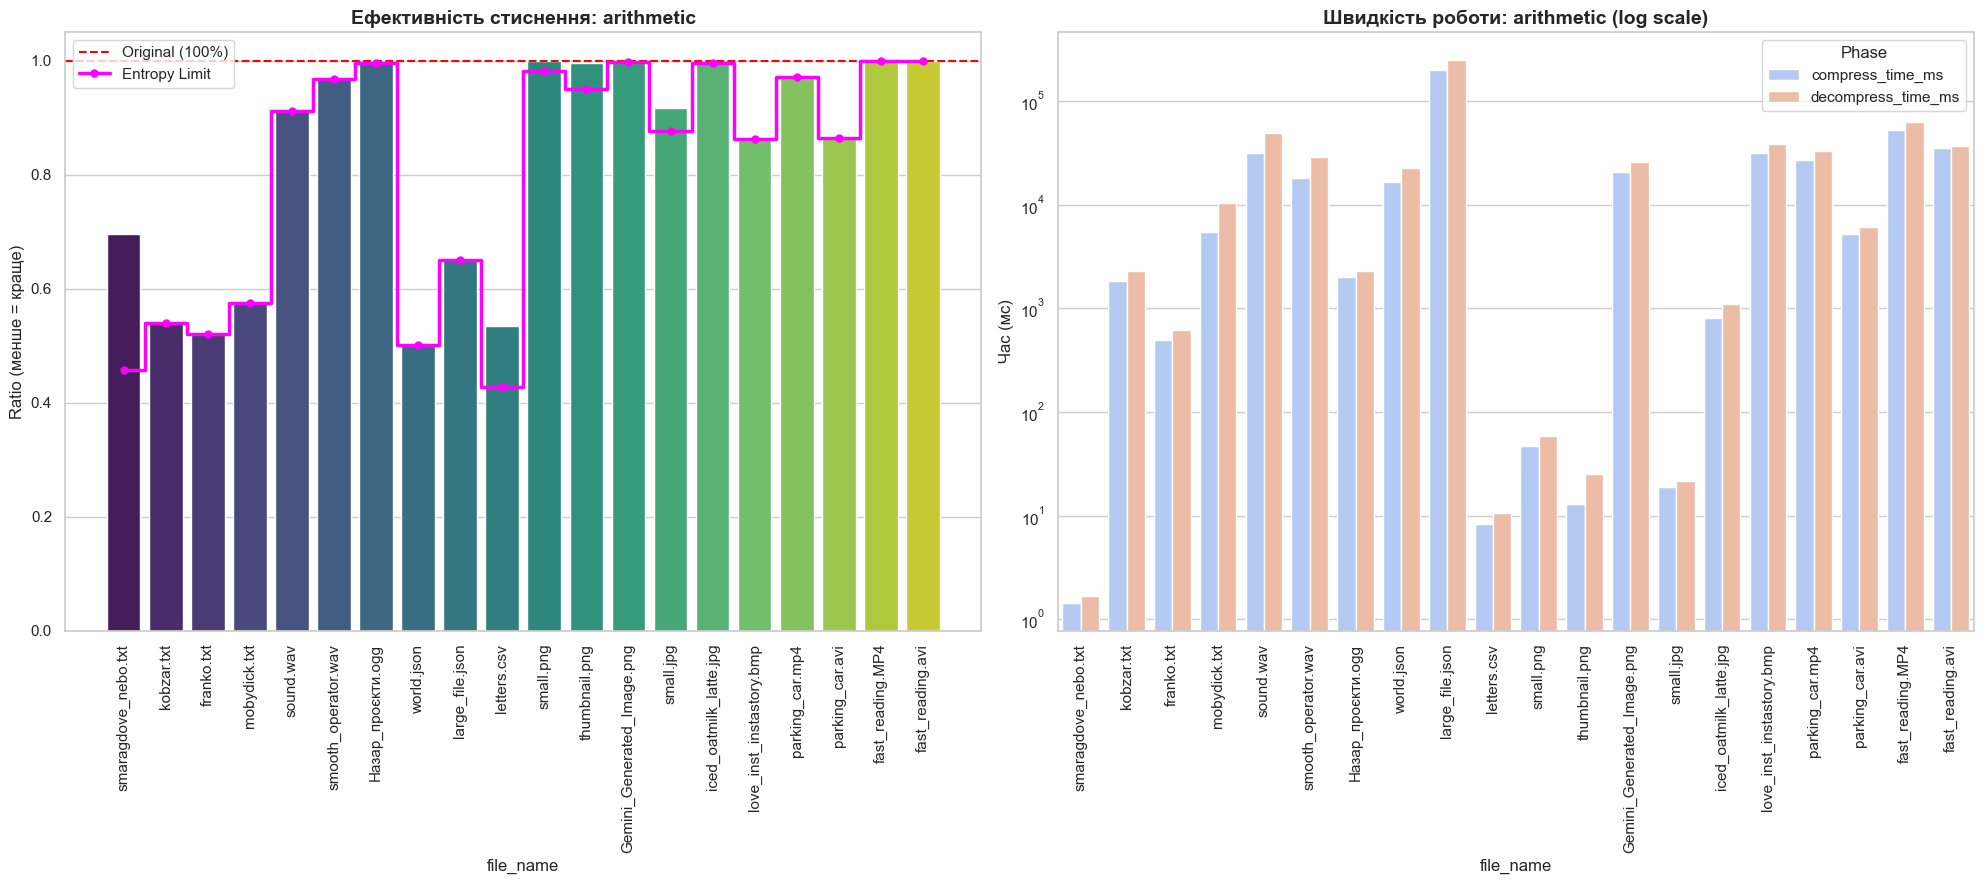


Детальна таблиця результатів для arithmetic:


,file_name,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,smaragdove_nebo.txt,0.6955,0.4578,1.417398,1.689434,True
17,parking_car.avi,0.8652,0.8648,5156.890631,6082.849264,True
16,parking_car.mp4,0.9715,0.9714,26978.749275,32653.625488,True
15,love_inst_instastory.bmp,0.8627,0.8626,31168.018341,38030.065536,True
14,iced_oatmilk_latte.jpg,0.9986,0.9964,805.797577,1097.237587,True
13,small.jpg,0.9173,0.8775,18.896341,21.693230,True
12,Gemini_Generated_Image.png,0.9978,0.9977,20567.438364,25741.505861,True
11,thumbnail.png,0.9972,0.9500,12.821436,25.376320,True
10,small.png,1.0003,0.9820,47.135353,59.047461,True
9,letters.csv,0.5353,0.4270,8.373260,10.665894,True


In [ ]:
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "mobydick.txt"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "thumbnail.png"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastory.bmp"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "parking_car.avi"),
    os.path.join("tests_samples", "fast_reading.MP4"),
    os.path.join("tests_samples", "fast_reading.avi")
]

run_single_algo_analysis(files_to_test, target_algo='arithmetic')


>>> Збір даних для алгоритму: arithmetic

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 153 bytes
  Ratio: 0.695x
  Compress time: 1.62 ms
  Decompress time: 1.55 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 546 bytes
  Ratio: 0.535x
  Compress time: 3.43 ms
  Decompress time: 5.26 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,973 -> 3,974 bytes
  Ratio: 1.000x
  Compress time: 18.00 ms
  Decompress time: 21.40 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,523 -> 1,397 bytes
  Ratio: 0.917x
  Compress time: 6.79 ms
  Decompress time: 7.98 ms


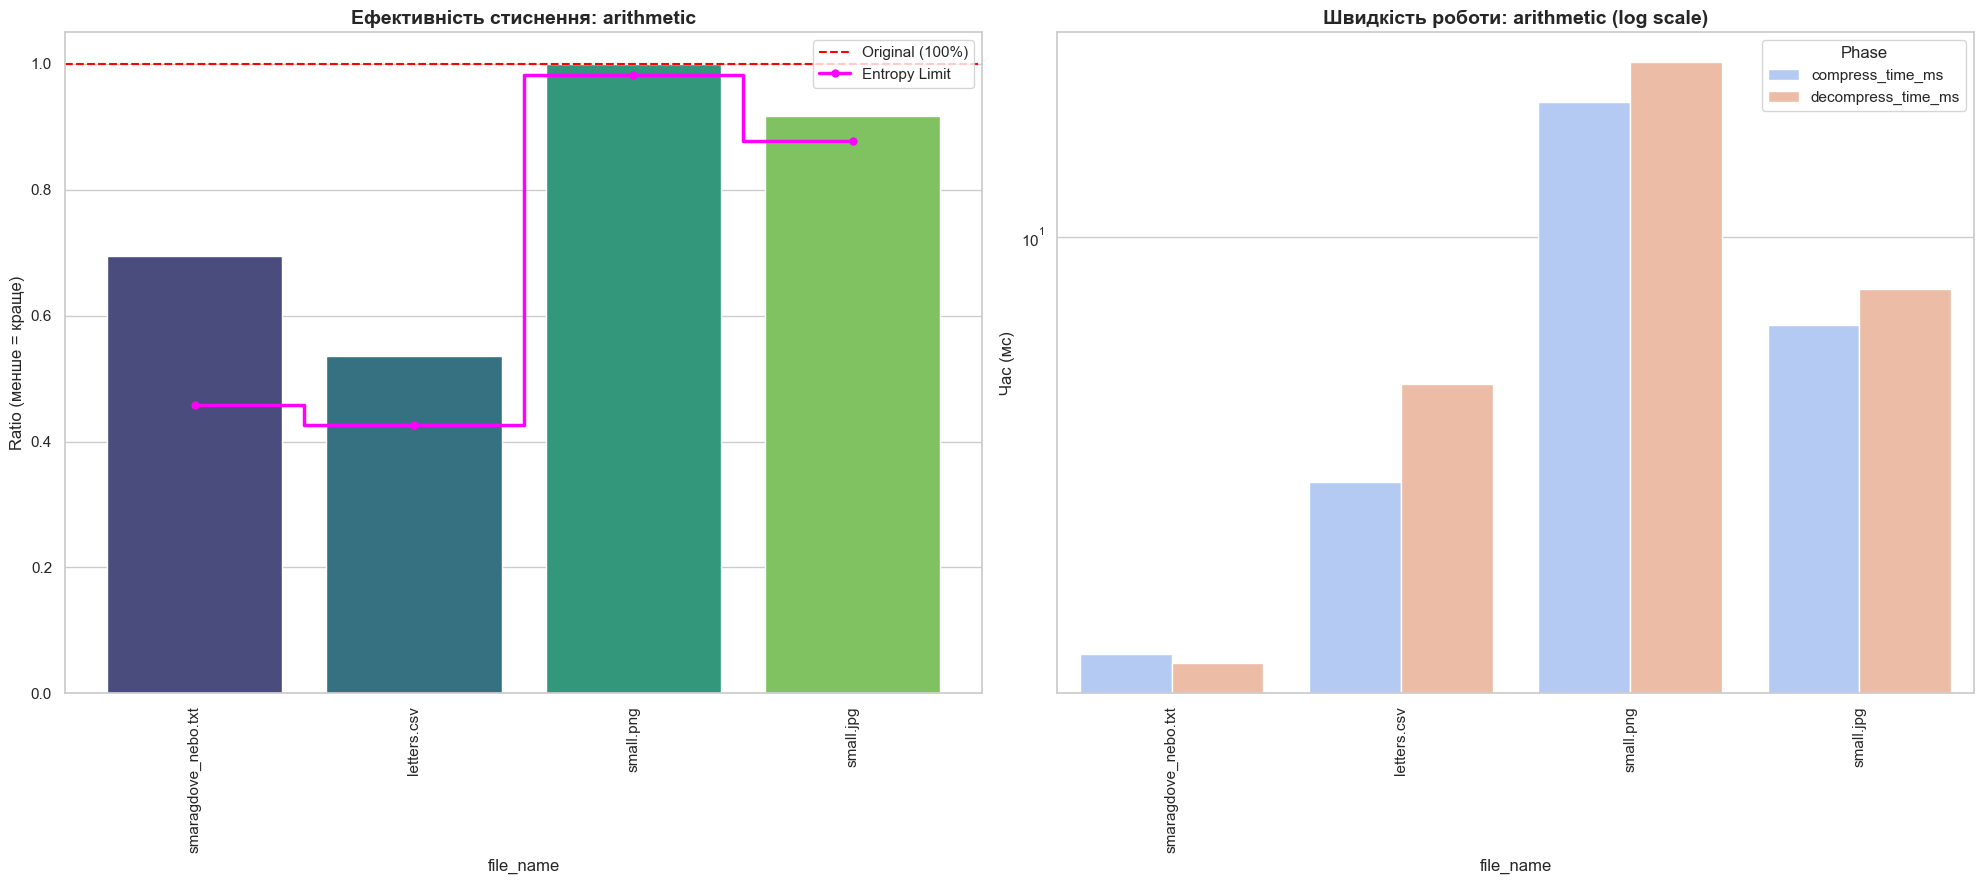


Детальна таблиця результатів для arithmetic:


,file_name,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,smaragdove_nebo.txt,0.6955,0.4578,1.615286,1.553774,True
1,letters.csv,0.5353,0.4270,3.431082,5.261660,True
2,small.png,1.0003,0.9820,18.001556,21.399260,True
3,small.jpg,0.9173,0.8775,6.793976,7.975578,True


In [ ]:
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "small.jpg")
]

run_single_algo_analysis(files_to_test, target_algo='arithmetic')


>>> Аналіз файлу: tests_samples\franko.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 46,158 bytes
  Ratio: 0.401x
  Compress time: 50.02 ms
  Decompress time: 18.91 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 77,272 bytes
  Ratio: 0.671x
  Compress time: 151961.30 ms
  Decompress time: 39.13 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 60,234 bytes
  Ratio: 0.523x
  Compress time: 992.53 ms
  Decompress time: 1479.74 ms

TESTING DEFLATE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 35,619 bytes
  Ratio: 0.309x
  Compress time: 148057.14 ms
  Decompress time: 272.76 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 115,090 -> 60,662 bytes
  Ratio: 0.527x
  Compress time: 162.1

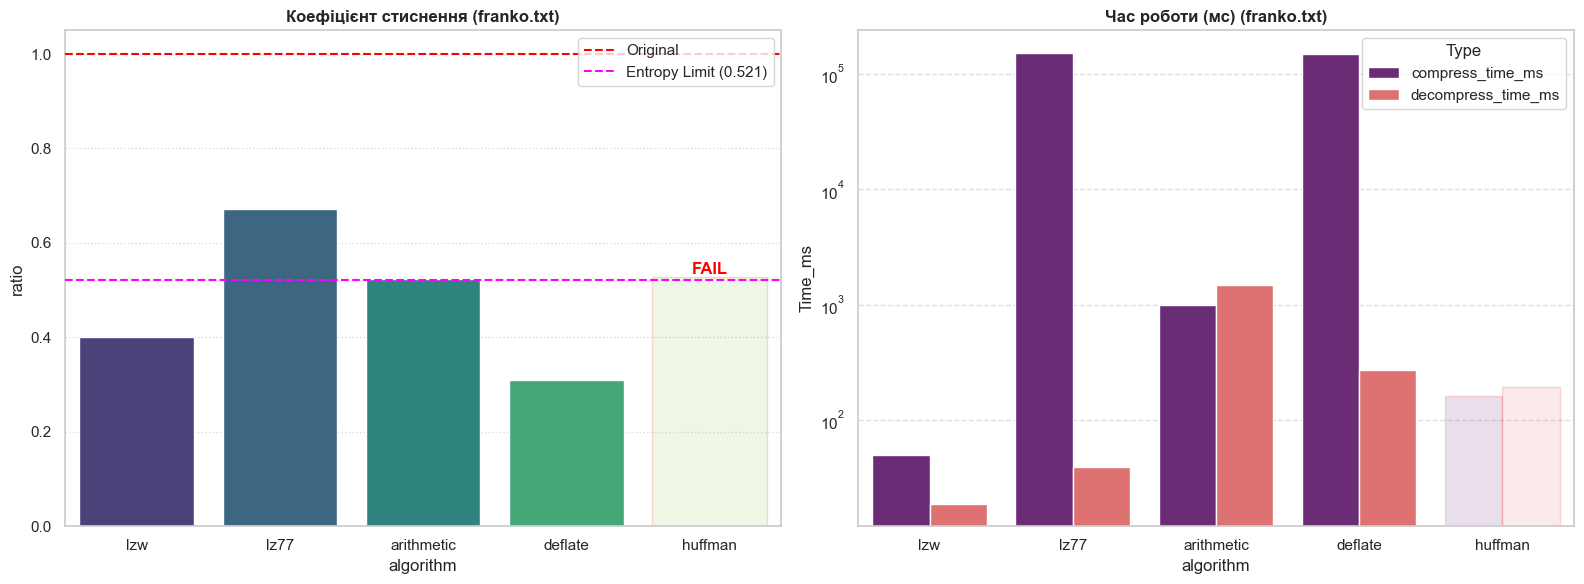

,algorithm,ratio,entropy_limit,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.401060,0.521018,50.017357,18.913746,True
1,lz77,0.671405,0.521018,151961.297035,39.125204,True
2,arithmetic,0.523364,0.521018,992.526770,1479.735851,True
3,deflate,0.309488,0.521018,148057.142019,272.756338,True
4,huffman,0.527083,0.521018,162.111521,192.173958,False


In [ ]:
algorithms = ['lzw', 'lz77', 'arithmetic', 'deflate', 'huffman']
files_to_test = [
    os.path.join("tests_samples", "franko.txt")
    ]

run_full_analysis(files_to_test, algorithms)

ЛЗМА

In [20]:
import os
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "mobydick.txt"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "small.png"),
    os.path.join("tests_samples", "thumbnail.png"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "small.jpg"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastory.bmp"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "parking_car.avi"),
    os.path.join("tests_samples", "fast_reading.MP4"),
    os.path.join("tests_samples", "fast_reading.avi")
]

run_single_algo_analysis(files_to_test, target_algo='lzma')


>>> Збір даних для алгоритму: lzma

TESTING LZMA
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 109 bytes
  Ratio: 0.495x
  Compress time: 6.21 ms
  Decompress time: 1.23 ms

TESTING LZMA
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 158,180 bytes
  Ratio: 0.378x
  Compress time: 5140.87 ms
  Decompress time: 1979.89 ms

TESTING LZMA
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 43,585 bytes
  Ratio: 0.379x
  Compress time: 5324.84 ms
  Decompress time: 1068.93 ms

TESTING LZMA
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,276,227 -> 617,058 bytes
  Ratio: 0.484x
  Compress time: 18495.16 ms
  Decompress time: 4887.63 ms

TESTING LZMA
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,340,750 bytes
  Ratio: 0.908x
  Compress time: 77646.23 ms
  Decompres

KeyboardInterrupt: 